In [11]:
import polars as pl
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

In [12]:
adfs = {}
ldfs = {}
for file in Path("../runs/test/lattices/").iterdir():
    time = int(file.name.replace(".parquet", ""))
    ldfs[time] = pl.read_parquet(file)
    adfs[time] = pl.read_parquet(str(file).replace("lattices", "act_lattices"))

In [29]:
_neighs = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]


def inbounds(x, y, w, h):
    if x < 0:
        return False
    if x > w - 1:
        return False
    if y < 0:
        return False
    if y > h - 1:
        return False
    return True


def neighs(x, y, w, h):
    return filter(lambda pos: inbounds(pos[0], pos[1], w, h), map(lambda pos: (pos[0] + x, pos[1] + y), _neighs))


# This is not quite what ava did.
# Try:
#   Using the geom mean of each pos
#   Taking the average per neighbour of the entire cell (use two NCELLS X NCELLS matrices to calculate the averages)
def act_sum(latdf: pl.DataFrame, actdf: pl.DataFrame):
    labels = []
    actvs = []
    for i in range(0, latdf.shape[0]):
        for j in range(0, latdf.shape[1]):
            for n in neighs(i, j, latdf.width, latdf.height):
                ij_sigma = latdf[i, j]
                if not ij_sigma.isnumeric():
                    continue
                n_sigma = latdf[*n]
                if ij_sigma == n_sigma:
                    continue
                act = abs(geom_mean((i, j), latdf, actdf) - geom_mean(n, latdf, actdf))
                if act == 0:
                    continue
                if n_sigma == "m":
                    lab = 0
                elif n_sigma.isnumeric():
                    lab = 1
                else:
                    continue
                actvs.append(act)
                labels.append(lab)
                
    return pl.DataFrame({
        "label": labels,
        "act": actvs
    })

def geom_mean(pos, latdf, actdf):
    pos_spin = latdf[*pos]
    act_prod = actdf[*pos]
    act_count = 1
    for neigh in neighs(pos[0], pos[1], latdf.width, latdf.height):
        if latdf[*neigh] != pos_spin:
            continue
        act_prod *= actdf[*neigh]
        act_count += 1
    return act_prod ** (1 / act_count)

In [30]:
asdf = act_sum(ldfs[3_400_000], adfs[3_400_000])

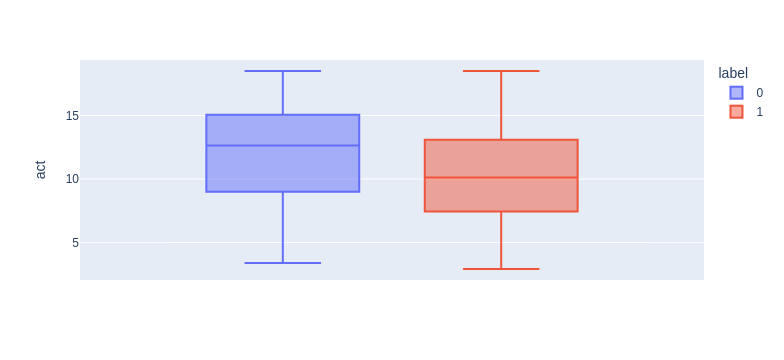

In [31]:
px.box(asdf, y="act", color="label")

In [11]:
asdf.group_by("label").mean()

label,act
i64,f64
0,3.522195
1,2.272909
